# Machine Learning Model on Refugee Population Forecasting and Humanitarian Resource Planning System for Kenya
___
**Team**: XG BOOST BUSTERS  
**Contributors**: Cynthia Jemutai, Stephen Jilani, Charity Nduati,Joy Njeru , Chris Karagu , Sylvia  Wambui

**Project**: Phase 5 Capstone Project   
**Data Sources**: [Kenya Refugee and Asylum Population Dataset](https://www..com/)
___

### 1. Introduction

Kenya accommodates populations displaced by conflict, persecution, climate shocks, and political instability originating from across the region including Somalia, South Sudan, the Democratic Republic of Congo, Ethiopia, Burundi, and Rwanda, among 39 origin countries identified in this dataset.

Several organizations work together to support refugees in Kenya:
1. **Department of Refugee Services (DRS)**: The Kenyan government agency responsible for refugee registration, camp management, policy implementation, and ensuring compliance with the Refugee Act of 2021.
2. **United Nations High Commissioner for Refugees (UNHCR)**: Coordinates the overall refugee response, manages refugee registration and data, mobilizes international funding, and promotes refugee protection.
3. **World Food Programme (WFP)**: Provides food assistance through food distribution and Cash and Voucher Assistance (CVA) programmes to improve food security.
4. **Kenya Red Cross Society (KRCS)**: Delivers frontline humanitarian services, including emergency medical care, disaster response, water supply, family tracing, and support for new refugee arrivals at border entry points.

Together, these organizations form an integrated humanitarian system that provides protection, food, healthcare, and essential services to refugees across Kenya.

### 2. Problem Statement

Kenya hosts one of the largest refugee populations in sub-Saharan Africa, making effective humanitarian planning essential. However, resource planning is often based on current or historical population data rather than future forecasts, limiting preparedness for sudden increases in refugee arrivals.

Key challenges identified from the HDX HAPI dataset include:

1. Rapid population changes that increase demand for food, healthcare, shelter, and other essential services.
2. Diverse demographic groups with different ages, genders, and vulnerabilities that require tailored support.
3. Different population categories (e.g., refugees and asylum seekers) with distinct humanitarian needs.
4. Delays in resource deployment, making it difficult to respond quickly to population surges.
5. Limited use of historical data for forecasting despite decades of available records.

These challenges highlight the need for a machine learning-based forecasting approach to support better resource planning and decision-making for refugee assistance in Kenya.

### 3. Project Objectives

#### 3.1 Primary Objective


To design, develop, and validate a machine learning forecasting system that predicts Kenya's refugee and asylum-seeker population levels disaggregated by origin country, population group, gender, and age cohort with a forecasting horizon of 6 to 24 months, and to translate these forecasts into quantified humanitarian resource planning recommendations.

#### 3.2 Specific Objectives


1. Explore the HDX HAPI Kenya dataset to identify population trends, demographic patterns, and changes over time.
2. Create relevant features to improve forecasting performance.
3. Develop and compare forecasting models to predict refugee population trends.
4. Generate population forecasts by refugee category, age, gender, and country of origin.
5. Estimate humanitarian resource needs based on the forecasted population.
6. Evaluate model performance using standard forecasting metrics (RMSE, MAE, and MAPE).
7. Provide recommendations to support data-driven humanitarian planning and decision-making in Kenya.

### 4. Data Understanding


The dataset used for this project is the Kenya Refugee and Asylum Population Dataset, obtained from the Humanitarian Data Exchange (HDX) platform.The dataset contains historical records of displaced populations hosted in Kenya and provides detailed demographic information necessary for forecasting refugee population trends and supporting humanitarian resource planning.

The dataset covers a 25-year period from 2001 to 2025, containing 27,664 records and 15 variables. Each record represents a population observation reported for a specific period, location, population category, gender, and age group.

The dataset includes four main population groups:

1. **Refugees (REF)**: Individuals who have been recognized as refugees and require international protection.
2. **Asylum Seekers (ASY)**: Individuals who have applied for refugee status and are awaiting determination.
3. **Host Community (HST)**: Members of the local population affected by refugee presence and humanitarian operations.
4. **Others of Concern (OOC)**: Individuals who require humanitarian assistance but do not fall under the refugee or asylum seeker categories.

The main target variable for this project is:

**Population**: The recorded number of individuals within each demographic category. 

**Key predictor variables**

| Column | Description |
|---|---|
| reference_period_start / end | Reporting period boundaries |
| asylum_location_code | Country where asylum is provided |
| origin_location_code | Country of origin of displaced population |
| population_group | Refugee population category |
| gender | Gender category (male/female) |
| age_range | Age cohort category |
| min_age / max_age | Age boundaries of the cohort |
| population | Number of individuals recorded (target) |

he dataset is well suited to this project because it contains long-term historical observations, demographic breakdowns, and population movement patterns required for machine learning forecasting.

#### 4.1 Loading of Data  and relevant Libraries

In [76]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [77]:
#load data
df = pd.read_csv("Kenya_Refugee.csv")
df.head()

,origin_location_code,origin_has_hrp,origin_in_gho,asylum_location_code,asylum_has_hrp,asylum_in_gho,population_group,gender,age_range,min_age,max_age,population,reference_period_start,reference_period_end
0,AFG,True,True,KEN,False,True,ASY,f,0-4,0,4,0,2020-01-01,2020-12-31
1,AFG,True,True,KEN,False,True,ASY,f,5-11,5,11,0,2020-01-01,2020-12-31
2,AFG,True,True,KEN,False,True,ASY,f,12-17,12,17,0,2020-01-01,2020-12-31
3,AFG,True,True,KEN,False,True,ASY,f,18-59,18,59,0,2020-01-01,2020-12-31
4,AFG,True,True,KEN,False,True,ASY,f,60+,60,None,0,2020-01-01,2020-12-31


#### 4.2 Data Overview

In [78]:
#total rows and columns
df.shape

(27664, 14)

In [79]:
#list columns
df.columns.tolist()

['origin_location_code',
 'origin_has_hrp',
 'origin_in_gho',
 'asylum_location_code',
 'asylum_has_hrp',
 'asylum_in_gho',
 'population_group',
 'gender',
 'age_range',
 'min_age',
 'max_age',
 'population',
 'reference_period_start',
 'reference_period_end']

*Dataset has 27,664 rows and 15 columns*

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27664 entries, 0 to 27663
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   origin_location_code    27664 non-null  object
 1   origin_has_hrp          27664 non-null  bool  
 2   origin_in_gho           27664 non-null  bool  
 3   asylum_location_code    27664 non-null  object
 4   asylum_has_hrp          27664 non-null  bool  
 5   asylum_in_gho           27664 non-null  bool  
 6   population_group        27664 non-null  object
 7   gender                  27664 non-null  object
 8   age_range               27664 non-null  object
 9   min_age                 27664 non-null  object
 10  max_age                 27664 non-null  object
 11  population              27664 non-null  int64 
 12  reference_period_start  27664 non-null  object
 13  reference_period_end    27664 non-null  object
dtypes: bool(4), int64(1), object(9)
memory usage: 2.2+ MB


The dataset contains a combination of categorical, numerical, and date-based variables.
An assessment of missing values shows that no missing values are present across the dataset variables.

In [81]:
df.describe()

,population
count,27664.000000
mean,1409.757591
std,13881.284560
min,0.000000
25%,0.000000
50%,0.000000
75%,17.000000
max,517666.000000


The descriptive statistic show that the population variable has a highly uneven distribution, ranging from **0 to 517,666 individuals** across 27,664 observations. The mean population of approximately **1,410** compared to a median of **0** indicates that many records represent small or zero population groups, while a few observations contain very large refugee populations.

This pattern is expected in humanitarian datasets because records are highly disaggregated by country of origin, age, gender, and population group. Zero values may represent valid cases where no individuals were recorded for a specific category and period, rather than missing data. Therefore, they will be retained and considered during modeling. The variation in population sizes highlights the need for machine learning approaches capable of capturing both stable population trends and sudden displacement changes.


### 5. Data Cleaning

Data cleaning was conducted to improve data quality and ensure that the dataset was suitable for exploratory analysis and machine learning forecasting. The cleaning process focused on selecting relevant records, removing duplicate representations, validating data completeness, correcting data types, and investigating unusual population values.

#### 5.1 Filtering relevant records

In [82]:
#filtering the data set to have only data  for refugees who took  assylum in kenya
df = df[df['asylum_location_code']=='KEN']
df

,origin_location_code,origin_has_hrp,origin_in_gho,asylum_location_code,asylum_has_hrp,asylum_in_gho,population_group,gender,age_range,min_age,max_age,population,reference_period_start,reference_period_end
0,AFG,True,True,KEN,False,True,ASY,f,0-4,0,4,0,2020-01-01,2020-12-31
1,AFG,True,True,KEN,False,True,ASY,f,5-11,5,11,0,2020-01-01,2020-12-31
2,AFG,True,True,KEN,False,True,ASY,f,12-17,12,17,0,2020-01-01,2020-12-31
3,AFG,True,True,KEN,False,True,ASY,f,18-59,18,59,0,2020-01-01,2020-12-31
4,AFG,True,True,KEN,False,True,ASY,f,60+,60,None,0,2020-01-01,2020-12-31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27659,ZWE,False,False,KEN,False,True,REF,m,12-17,12,17,0,2025-01-01,2025-12-31
27660,ZWE,False,False,KEN,False,True,REF,m,18-59,18,59,0,2025-01-01,2025-12-31
27661,ZWE,False,False,KEN,False,True,REF,m,60+,60,None,0,2025-01-01,2025-12-31
27662,ZWE,False,False,KEN,False,True,REF,m,all,None,None,8,2025-01-01,2025-12-31


The dataset was first filtered to include only records where the asylum location was Kenya. This ensured that the analysis focused specifically on refugee and asylum populations hosted within Kenya, aligning with the project's objective of forecasting humanitarian needs in the country.

#### 5.2 Checking Missing Values and Duplicates

The dataset was assessed for missing values and duplicate records. The analysis showed that there were no missing values across the variables, indicating that the dataset was complete and did not require missing value imputation. Duplicate records were also checked to ensure that repeated observations would not affect population estimates or model performance.

In [83]:
#missing values
print('Missing values per column:')
print(df.isnull().sum())
print('\n')
#duplicate
print('Duplicate :', df.duplicated().sum())

Missing values per column:
origin_location_code      0
origin_has_hrp            0
origin_in_gho             0
asylum_location_code      0
asylum_has_hrp            0
asylum_in_gho             0
population_group          0
gender                    0
age_range                 0
min_age                   0
max_age                   0
population                0
reference_period_start    0
reference_period_end      0
dtype: int64


Duplicate : 0


#### 5.3 Handling Aggregated Categories

The dataset contained aggregated categories represented as "all" in the gender and age range variables. These categories were reviewed to determine whether they would affect population analysis.




In [84]:
# Display the unique gender categories in the dataset
df['gender'].unique()

array(['f', 'm', 'all'], dtype=object)

In [85]:
#we noticed that the all column was an addition of the males and female which would lead to duplication
#drop 'all' on gender
df = df[df['gender'] != 'all']
print(df['gender'].unique())

['f' 'm']


The "all" gender category was removed because it represents the combined total of male and female populations. Keeping this category alongside the individual male and female records would result in duplicate population counts and inflate population estimates.

In [86]:
# Display the unique age range categories in the dataset
df['age_range'].unique()

array(['0-4', '5-11', '12-17', '18-59', '60+', 'all'], dtype=object)

In [87]:
#Checking the frequency distribution of the age range category
df['age_range'].value_counts()

60+      1708
0-4      1708
all      1708
5-11     1708
18-59    1708
12-17    1708
Name: age_range, dtype: int64

The dataset contained five defined age cohorts (0–4, 5–11, 12–17, 18–59, and 60+) as well as an aggregated `"all"` category.

In [88]:
# Drop the aggregated 'all' age category for the same reason as gender
df = df[df['age_range'] != 'all']
df['age_range'].unique()

array(['0-4', '5-11', '12-17', '18-59', '60+'], dtype=object)

The "all" category was removed because it represents an aggregated population total rather than a distinct age cohort. Including it alongside individual age groups could introduce overlapping population information and affect age-specific analysis and forecasting.

The 60+ category was intentionally left without an artificial maximum age, since it represents an open-ended age group; introducing a fixed upper limit would create an unsupported assumption about elderly population estimates.

#### 5.4 Validating Population Values

The population variable was examined to understand its distribution and identify potential data quality issues. The analysis showed that population values ranged from zero to very large population counts. A significant number of records contained zero population values.

Further investigation showed that zero values occurred across different: population groups,gender categories,and age ranges.



In [89]:
#checking distribution
df['population'].describe()

count      8540.000000
mean       1384.064988
std        6681.813404
min           0.000000
25%           0.000000
50%           6.000000
75%         156.000000
max      115273.000000
Name: population, dtype: float64

In [90]:
# Display the unique population group categories in the dataset
df['population_group'].unique()

array(['ASY', 'REF', 'HST', 'OOC'], dtype=object)

In [91]:
# Where do the zero-population records come from?
print("Zero population by group:\n", df[df['population'] == 0]['population_group'].value_counts())
print("\nZero population by gender:\n", df[df['population'] == 0]['gender'].value_counts())
print("\nZero population by age range:\n", df[df['population'] == 0]['age_range'].value_counts())
print(f"\nShare of records with zero population: {(df['population'] == 0).mean()*100:.1f}%")

Zero population by group:
 ASY    2084
REF    1498
OOC     140
HST      60
Name: population_group, dtype: int64

Zero population by gender:
 f    1971
m    1811
Name: gender, dtype: int64

Zero population by age range:
 60+      1017
0-4       852
12-17     733
5-11      728
18-59     452
Name: age_range, dtype: int64

Share of records with zero population: 44.3%


Approximately 44% of observations have zero population counts. This is expected in a highly disaggregated refugee dataset where many demographic combinations may have no recorded individuals during a reporting period. Since zeros occur across multiple groups and are not associated with a specific data quality issue, they were retained as valid observations.

Retaining zero values allows the forecasting model to learn both population growth patterns and periods of low or absent population presence, improving its ability to support realistic humanitarian planning.

#### 5.5 Converting Date Variables

In [92]:
# Convert reporting period to datetime and derive a single 'year' feature
df['reference_period_start'] = pd.to_datetime(df['reference_period_start'])
df['reference_period_end'] = pd.to_datetime(df['reference_period_end'])

df['year'] = df['reference_period_start'].dt.year
df.drop(columns=['reference_period_start', 'reference_period_end'], inplace=True)


#### 5.6 Handling Extreme Population Values

The population distribution was reviewed using  boxplots.

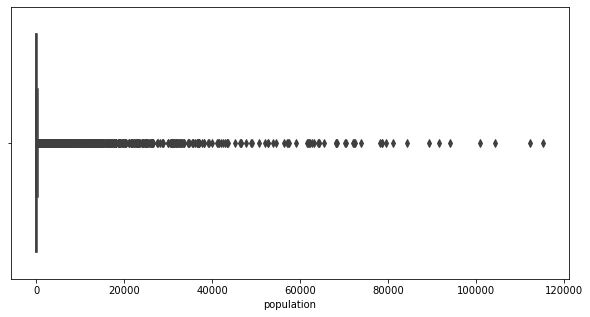

In [94]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['population'])
plt.show()

The variable showed a highly right-skewed distribution, with a small number of very large population counts. These extreme values were retained because they represent genuine large refugee populations and are important for humanitarian resource planning. Removing them would reduce the model's ability to capture large-scale displacement events.

#### 5.7 Final Validation of data

In [128]:
print(df.shape)
df.info()
df.head()

(8540, 13)
<class 'pandas.core.frame.DataFrame'>
Int64Index: 8540 entries, 0 to 27661
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   origin_location_code  8540 non-null   object
 1   origin_has_hrp        8540 non-null   int32 
 2   origin_in_gho         8540 non-null   int32 
 3   asylum_location_code  8540 non-null   object
 4   asylum_has_hrp        8540 non-null   bool  
 5   asylum_in_gho         8540 non-null   bool  
 6   population_group      8540 non-null   object
 7   gender                8540 non-null   object
 8   age_range             8540 non-null   object
 9   min_age               8540 non-null   object
 10  max_age               8540 non-null   object
 11  population            8540 non-null   int64 
 12  year                  8540 non-null   int64 
dtypes: bool(2), int32(2), int64(2), object(7)
memory usage: 1.0+ MB


,origin_location_code,origin_has_hrp,origin_in_gho,asylum_location_code,asylum_has_hrp,asylum_in_gho,population_group,gender,age_range,min_age,max_age,population,year
0,AFG,1,1,KEN,False,True,ASY,f,0-4,0,4,0,2020
1,AFG,1,1,KEN,False,True,ASY,f,5-11,5,11,0,2020
2,AFG,1,1,KEN,False,True,ASY,f,12-17,12,17,0,2020
3,AFG,1,1,KEN,False,True,ASY,f,18-59,18,59,0,2020
4,AFG,1,1,KEN,False,True,ASY,f,60+,60,None,0,2020


Zero population values are observed across all age groups, with the largest number occurring among children aged 0–4 years. Since the zeros are spread throughout the age categories rather than concentrated in a single group, they are more likely to represent valid observations than systematic data errors. The zero values will be retained because there is no evidence that they are caused by age-specific reporting problems.

**6. EXPLORATORY DATA ANALYSIS**

**UNIVARIATE ANALYSIS**

All variables in the dataset except population are categorical and repeat throughout the dataset with equal frequency, so univariate counts add limited insight. The remainder of the EDA therefore focuses on bivariate and multivariate analysis, which reveal how population varies across categories.

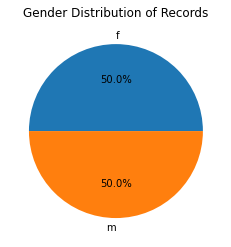

In [129]:
df['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Gender Distribution of Records")
plt.ylabel("")
plt.show()

The graph shows that there is a balanced disttribution of all the age ranges as represented in the dataset.

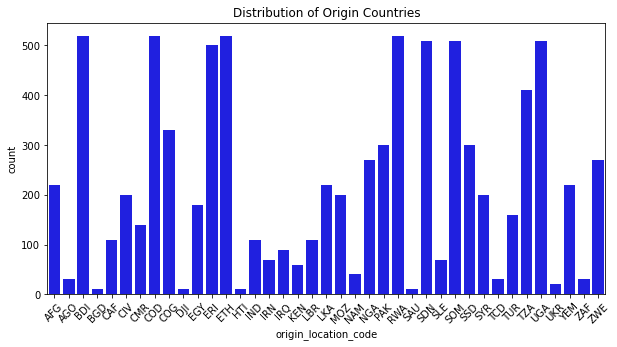

In [100]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="origin_location_code",
    order=sorted(df["origin_location_code"].unique()),
    color='blue'
)

plt.title("Distribution of Origin Countries")
plt.xticks(rotation=45)
plt.show()

The plot shows the representation of different refugee origin countries within the dataset. The number of records varies across countries due to differences in reporting frequency and duration of refugee presence. This provides an understanding of data coverage across origin countries before further population analysis.



**BIVARIATE ANALYSIS**

<function matplotlib.pyplot.show(close=None, block=None)>

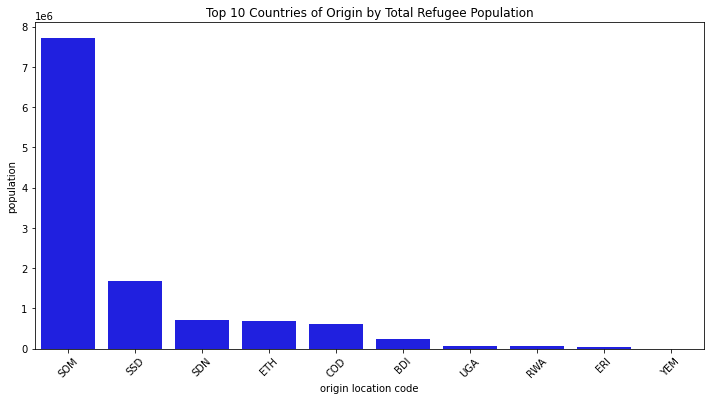

In [101]:
#A graph of countries against the population. This is to show where most refugees have come from across the dataset.

#Grouping origin location codes and finding the total population for each one of them.
country_population = (
    df.groupby('origin_location_code')['population']
        .sum()
        .reset_index()
)

top_10 = (
    country_population
    .sort_values(by = 'population', ascending = False)
    .head(10)
)

#Plotting the bar based on the grouped data above.
plt.figure(figsize=(12,6))

sns.barplot(data=top_10, x= 'origin_location_code', y = 'population', color='blue')

plt.title("Top 10 Countries of Origin by Total Refugee Population")
plt.xlabel("origin location code")
plt.ylabel("population")
plt.xticks(rotation=45)
plt.show


**Interepretation of the origin location vs population graph**

Based on the above bar chart, the maximum refugees that end up in Kenya are from Somalia,followed by Southsudan by a very big distance followed by Sudan,Ethiopia and Congo. This is to say that Kenyan refugees comes from the immediate neignbbouring countries rather than countries that involve crossing multiple borders to get to Kenya.

In [102]:
#Running the dataframe for visibility
df.head()

,origin_location_code,origin_has_hrp,origin_in_gho,asylum_location_code,asylum_has_hrp,asylum_in_gho,population_group,gender,age_range,min_age,max_age,population,year
0,AFG,True,True,KEN,False,True,ASY,f,0-4,0,4,0,2020
1,AFG,True,True,KEN,False,True,ASY,f,5-11,5,11,0,2020
2,AFG,True,True,KEN,False,True,ASY,f,12-17,12,17,0,2020
3,AFG,True,True,KEN,False,True,ASY,f,18-59,18,59,0,2020
4,AFG,True,True,KEN,False,True,ASY,f,60+,60,None,0,2020


<function matplotlib.pyplot.show(close=None, block=None)>

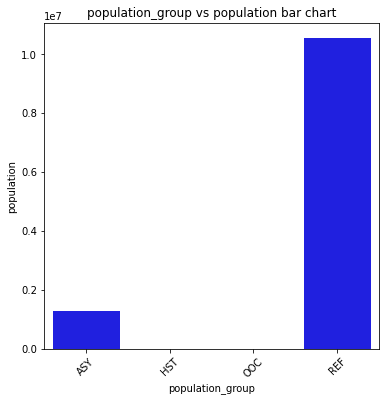

In [103]:
#The plot below is for population group which is either asylum or refugee etc against population

#creating a variable which groups the data by population group and computes the total population of each.
population_g_population = (
    df.groupby('population_group')['population']
        .sum()
        .reset_index()
)

#Plotting the bar graph
plt.figure(figsize=(6,6))

sns.barplot(data=population_g_population, x= 'population_group', y = 'population', color='blue')

plt.title("population_group vs population bar chart")
plt.xlabel("population_group")
plt.ylabel("population")
plt.xticks(rotation=45)
plt.show

**Interepretation of the origin location vs population graph**

The bar graph stresses on 2 categories which is Refugee and Asylum. With refugees being the people who receive their official status of being refugees while int heir origin country while asylum seekers receive their official status while already in the destination country.

However it is, the refugees are the majority 10-foled. This is a good indicator for humanitarian organizations in resource planning as most individuals are already identified while they are still in their country of origin. This gives lead time before they arrive in the destination country.

The other 2 categories are for Host Community and Others of Concern. These form a very negligible part of the data and aren't expected to have much impact on the final models.

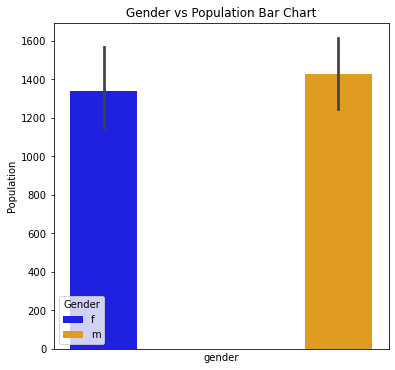

In [104]:
plt.figure(figsize=(6,6))

sns.barplot(
    data=df,
    x='gender',
    y='population',
    hue='gender',
    palette={'m': 'orange', 'f': 'blue'}
)

plt.title("Gender vs Population Bar Chart")
plt.xticks([])
plt.ylabel("Population")
plt.legend(title='Gender',)
plt.show()

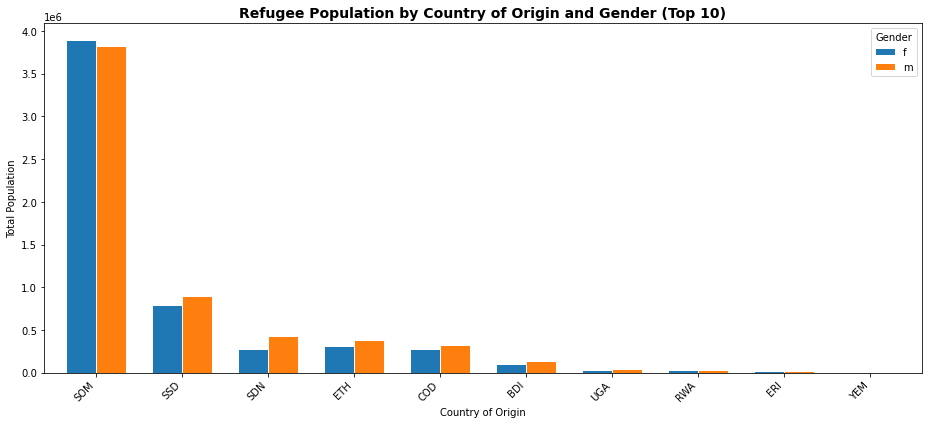

In [105]:
# Get top 10 countries by total population
top10_countries = (
    df.groupby('origin_location_code')['population']
      .sum()
      .nlargest(10)
      .index
)

country_gender = pd.pivot_table(
    df[df['origin_location_code'].isin(top10_countries)],
    values='population',
    index='origin_location_code',
    columns='gender',
    aggfunc='sum'
)


# Sort by total population descending
country_gender['total'] = country_gender.sum(axis=1)
country_gender = (
    country_gender.sort_values('total', ascending=False)
                  .drop('total', axis=1)
)

country_gender.plot(
    kind='bar',
    figsize=(13, 6),
    color=['tab:blue', 'tab:orange'],  # Female = blue, Male = orange
    edgecolor='white',
    width=0.7
)

plt.title(
    'Refugee Population by Country of Origin and Gender (Top 10)',
    fontsize=14,
    fontweight='bold'
)
plt.ylabel('Total Population')
plt.xlabel('Country of Origin')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

**Interepretation of the graph**

The nearly equal proportion of men and women suggests that displacement from the main countries of origin affects both genders at similar rates. For humanitarian planners, this indicates that gender-responsive interventions should receive balanced funding and staffing.

<function matplotlib.pyplot.show(close=None, block=None)>

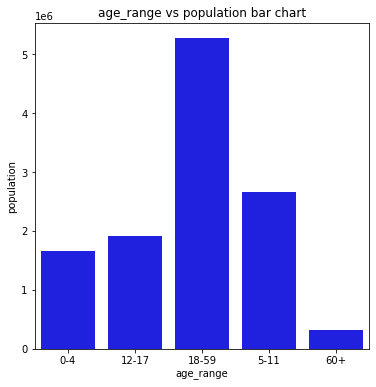

In [106]:
#Plotting a baer chart for age range against population

#Grouping age range and getting the total of population for each category
age_range_population = (
    df.groupby('age_range')['population']
        .sum()
        .reset_index()
)

#Plotting the figure

plt.figure(figsize=(6,6))

sns.barplot(data=age_range_population, x= 'age_range', y = 'population', color='blue')

plt.title("age_range vs population bar chart")
plt.xlabel("age_range")
plt.ylabel("population")
#plt.xticks(rotation=45)
plt.show

**Interepretation of the graph**

The 18–59 age group forms the largest share of the population due to its broad age range. Children (0–17) also make up a significant proportion, highlighting the need for education, child protection, and nutrition services. Although the 60+ group is the smallest, it has the greatest healthcare needs. The UNHCR Age, Gender and Diversity (AGD) framework emphasizes planning based on age- and gender-disaggregated data to meet these diverse needs.


<function matplotlib.pyplot.show(close=None, block=None)>

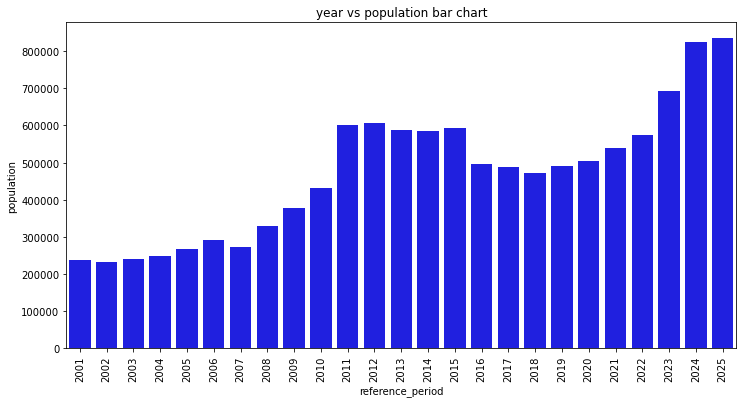

In [107]:
#Plotting a bar chart for the reference years against population

#Grouping the data based on years and then finding the sum of each.
period_population = (
    df.groupby('year')['population']
        .sum()
        .reset_index()
)

#Plotting thebar

plt.figure(figsize=(12,6))

sns.barplot(data=period_population, x= 'year', y = 'population', color='blue')

plt.title("year vs population bar chart")
plt.xlabel("reference_period")
plt.ylabel("population")
plt.xticks(rotation=90)
plt.show

**Interepretation of the graph**

The trend shows three phases: rapid growth (2001–2011), a period of stability and slight decline (2012–2019), and renewed growth from 2020 onward due to escalating regional conflicts. This non-linear pattern demonstrates that simple trend-based forecasting is inadequate, highlighting the need for machine learning models that can better capture complex population dynamics.


**MULTIVARIATE ANALYSIS**

Multivariate analysis examines relationships among three or more variables simultaneously. This helps uncover complex demographic patterns that may not be visible through univariate or bivariate analysis.

For humanitarian organizations, understanding how age, gender, country of origin, and population interact is essential for effective resource planning and forecasting.

The four analyses below move from demographic composition to country-gender dynamics to origin dominance to temporal trends, building
a complete picture of Kenya's refugee population structure.

**Age Range, Gender and Population**

### Business Question

How is the refugee population distributed across different age groups and genders?

Understanding the demographic composition of refugee populations can help humanitarian agencies allocate healthcare, education, protection services, and livelihood programs more effectively.

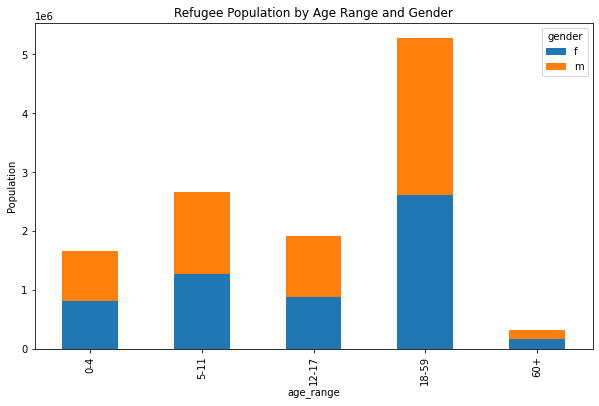

In [108]:
age_gender = pd.pivot_table(
    df,
    values='population',
    index='age_range',
    columns='gender',
    aggfunc='sum'
)
age_order = ['0-4', '5-11', '12-17', '18-59', '60+']
age_gender = age_gender.reindex(age_order)
age_gender.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Refugee Population by Age Range and Gender')
plt.ylabel('Population')
plt.show()

### Observation

The 18–59 working-age group is the largest demographic for both males and females, reflecting that displacement is primarily experienced by adults escaping conflict or persecution. Children aged 0–17 also make up a considerable share of the population, while those aged 60 and above represent the smallest group. Gender distribution remains relatively balanced across all age categories, with no significant dominance by either males or females.


### Business Insight

The demographic profile has important planning implications. The large 18–59 population drives demand for livelihood, skills training, and adult mental health services. The sizeable 0–17 population requires continued investment in education, nutrition, and child protection. Although the 60+ group is small, it has greater healthcare needs, consistent with the UNHCR Age, Gender and Diversity (AGD) framework. The balanced gender distribution also calls for equitable provision of gender-responsive services, including reproductive healthcare, GBV prevention, and psychosocial support.


**Country of Origin, Gender and Population**

### Business Question

How does gender composition vary across top refugee-producing countries?

Understanding gender patterns across countries of origin helps humanitarian agencies identify vulnerable populations and design targeted interventions.

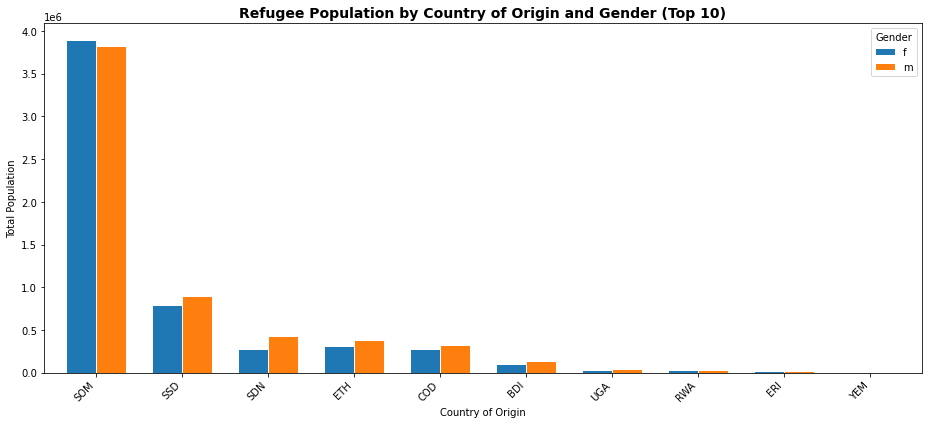

In [109]:
# Get top 10 countries by total population
top10_countries = (
    df.groupby('origin_location_code')['population']
      .sum()
      .nlargest(10)
      .index
)

country_gender = pd.pivot_table(
    df[df['origin_location_code'].isin(top10_countries)],
    values='population',
    index='origin_location_code',
    columns='gender',
    aggfunc='sum'
)


# Sort by total population descending
country_gender['total'] = country_gender.sum(axis=1)
country_gender = (
    country_gender.sort_values('total', ascending=False)
                  .drop('total', axis=1)
)

country_gender.plot(
    kind='bar',
    figsize=(13, 6),
    color=['tab:blue', 'tab:orange'],  # Female = blue, Male = orange
    edgecolor='white',
    width=0.7
)

plt.title(
    'Refugee Population by Country of Origin and Gender (Top 10)',
    fontsize=14,
    fontweight='bold'
)
plt.ylabel('Total Population')
plt.xlabel('Country of Origin')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

### Observation

Somalia (SOM) is the largest source country by far, followed by South Sudan (SSD), DRC, Ethiopia (ETH), Sudan (SDN), and Burundi (BDI). Gender distribution is generally balanced, with Somalia showing a slight female majority, while Ethiopia and Eritrea display more balanced or slightly male-leaning patterns, reflecting differences in displacement dynamics.


### Business Insight

The high concentration of refugees from Somalia and South Sudan means that forecasting these two populations is critical to the effectiveness of the planning system. Inaccuracies for these countries would have a greater impact on resource allocation than errors involving smaller origin groups. Gender patterns also influence programme needs: female-majority populations may require increased support for female-headed households, including protection, shelter, and livelihood assistance, while balanced or male-skewed populations may reflect different migration patterns requiring tailored psychosocial and economic support. Countries experiencing recent population growth should be closely monitored for changing gender trends that may affect future planning.



**Top 10 Countries of Origin vs Relative Population Share (Treemap)**

### Business Question

Which origin countries contribute the largest total refugee populations
to Kenya, and how stark is the concentration among the top contributors
relative to the rest?

In [110]:
pip install squarify

Note: you may need to restart the kernel to use updated packages.


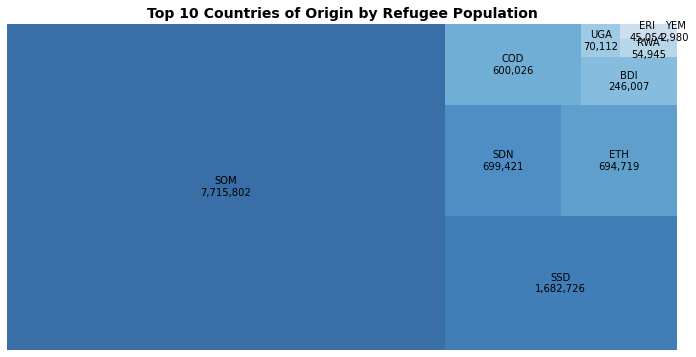

In [111]:
import squarify

# Top 10 countries by population
country_pop = (
    df.groupby('origin_location_code')['population']
      .sum()
      .nlargest(10)
)

# Labels
labels = [f"{c}\n{v:,.0f}" for c, v in country_pop.items()]

plt.figure(figsize=(12, 6))

squarify.plot(
    sizes=country_pop.values,
    label=labels,
    color=plt.cm.Blues(range(230, 30, -20)),
    alpha=0.8
)

plt.title('Top 10 Countries of Origin by Refugee Population',
          fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

### Observation

The treemap highlights the strong concentration of refugee populations among a few origin countries. Somalia represents the largest share by far, followed by South Sudan, while DRC, Ethiopia, Sudan, and Burundi contribute smaller but significant proportions. The remaining top 10 countries account for only a limited share, and the exclusion of around 29 other origin countries further demonstrates the dominance of the largest sources.
.

### Business Insight

The concentration of refugee populations in a few origin countries has important implications for ML forecasting. High-volume countries such as Somalia, South Sudan, DRC, Ethiopia, and Sudan should have separate models to improve accuracy, while smaller groups are better suited to simpler pooled approaches to reduce overfitting. Since Somalia has the greatest impact on overall estimates, accurate forecasting is essential. Emerging instability in mid-sized sources like Ethiopia and DRC also requires ongoing monitoring, as their displacement trends may change significantly over the next few years.



**Population Group by Age group**

How are the four population groups (REF, ASY, HST, OOC) distributed across age cohorts, and what does this imply for group-specific humanitarian programming?

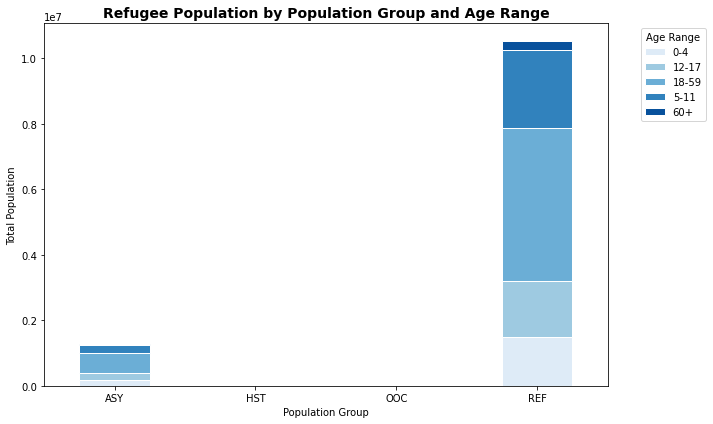

In [112]:
pop_group_age = pd.pivot_table(
    df,
    values='population',
    index='population_group',
    columns='age_range',
    aggfunc='sum'
)

pop_group_age.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=['#DEEBF7', '#9ECAE1', '#6BAED6', '#3182BD', '#08519C'],
    edgecolor='white'
)

plt.title('Refugee Population by Population Group and Age Range',
          fontsize=14, fontweight='bold')
plt.ylabel('Total Population')
plt.xlabel('Population Group')
plt.xticks(rotation=0)
plt.legend(title='Age Range', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Year of Assylum, Country of Origin and Population**


How have refugee population trends evolved over time for the five largest
origin countries?

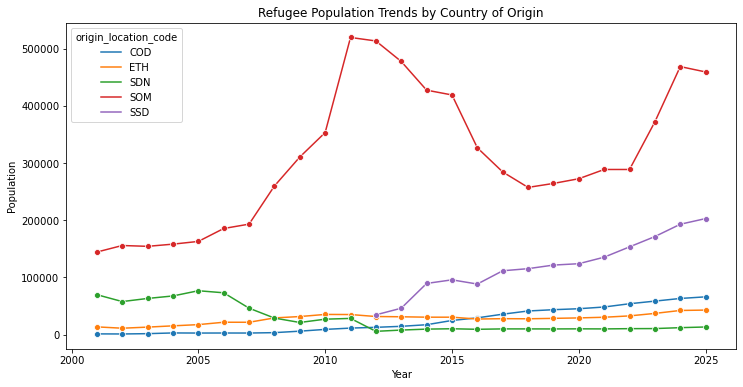

In [113]:

top_countries = (
    df.groupby('origin_location_code')['population']
      .sum()
      .nlargest(5)
      .index
)

year_country = (
    df[df['origin_location_code'].isin(top_countries)]
      .groupby(['year','origin_location_code'])['population']
      .sum()
      .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=year_country,
    x='year',
    y='population',
    hue='origin_location_code',
    marker='o'
)

plt.title('Refugee Population Trends by Country of Origin')
plt.xlabel('Year')
plt.ylabel('Population')

plt.show()

### Observation

Somalia (SOM) remains the largest source population from 2001–2025, with major increases around 2011, a slight decline during the mid-2010s, and renewed growth after 2020. South Sudan (SSD) experienced a sharp rise from 2013 following the civil war, becoming the second-largest origin group. Ethiopia (ETH) and DRC (COD) show persistent but smaller populations, with Ethiopia increasing after 2020 due to the Tigray conflict, while Sudan (SDN) shows a steady recent rise.


### Business Insight

The trends highlight three key implications for the forecasting system. First, refugee movements are driven by major events rather than steady patterns, requiring ML models to capture sudden changes and incorporate external conflict indicators. Second, prolonged displacement is common, meaning models must account for stable long-term populations alongside crisis-related increases. Third, simultaneous growth across multiple countries after 2020 suggests regional instability, making multi-country surge scenarios essential for effective planning.


# Exploratory Data Analysis Summary

The exploratory data analysis provided valuable insights into refugee population dynamics in Kenya.

Key findings include:

- Refugee populations are unevenly distributed, with a few demographic groups and countries contributing the largest populations.
- The working-age population (18–59 years) forms the largest age segment among refugees hosted in Kenya.
- Both male and female refugees contribute significantly to the overall population.
- Refugee populations originate from multiple countries, although a small number of countries account for the majority of refugee inflows.
- Population trends vary over time, highlighting the dynamic nature of displacement and the importance of predictive analytics.
- Demographic patterns differ across age groups, genders, and countries of origin, suggesting varying humanitarian needs.

These findings provide a strong foundation for feature engineering and predictive modeling. The identified demographic and temporal patterns will support the development of machine learning models capable of forecasting refugee population changes and improving humanitarian resource planning in Kenya.

## 6.Preprocessing

In [114]:
# importing relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score,accuracy_score,classification_report,confusion_matrix,f1_score)
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor



 Reproducing a cleaned dataset

In [115]:
#converting categorical data to numerical  data
df['origin_has_hrp'] = df['origin_has_hrp'].astype(int)
df['origin_in_gho'] = df['origin_in_gho'].astype(int)

In [116]:
categorical_cols = ['origin_location_code', 'population_group', 'gender', 'age_range']
base_num_cols = ['origin_has_hrp', 'origin_in_gho', 'year']

X = df[categorical_cols + base_num_cols].copy()
y = df['population'].copy()

# Chronological split for a time-series-style evaluation
train_mask = df['year'] <= 2022
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print(X_train.shape, X_test.shape)

(7060, 7) (1480, 7)


Since this is a time series forecasting problem, the data was split chronologically rather than randomly. Earlier observations were used for training, while more recent observations were reserved for testing. This prevents information from future periods leaking into the training data and provides a realistic evaluation of the model's forecasting performance. Having a larger train set means that the model has enough data to learn underlying patterns and still maintain enough data to test the validation of the model in real world situations. 

In [117]:
def build_pipeline(model, categorical_cols):
    preprocess = ColumnTransformer(
        [('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)],
        remainder='passthrough'
    )
    return Pipeline([('prep', preprocess), ('model', model)])

def evaluate(pipe, X_tr, y_tr, X_te, y_te, name):
    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_te)
    mae = mean_absolute_error(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    r2 = r2_score(y_te, pred)
    print(f"{name:35s} MAE: {mae:9.2f}   RMSE: {rmse:9.2f}   R2: {r2:7.3f}")
    return mae, rmse, r2, pred

In [118]:
from sklearn.linear_model import LinearRegression

lr_pipe = build_pipeline(
    LinearRegression(),
    categorical_cols
)

lr_mae, lr_rmse, lr_r2, lr_pred = evaluate(
    lr_pipe,
    X_train,
    y_train,
    X_test,
    y_test,
    "Linear Regression"
)

Linear Regression                   MAE:   2174.58   RMSE:   5005.01   R2:   0.429


In [119]:
# Make predictions using Linear Regression model
linear_predictions = lr_pred

# Display actual vs predicted values
prediction_results = pd.DataFrame({
    "Actual Population": y_test.values,
    "Predicted Population": linear_predictions
})

prediction_results.head(20)

,Actual Population,Predicted Population
0,5,-1817.866026
1,7,-1274.368151
2,0,-1702.861069
3,35,198.610603
4,0,-2603.848321
5,0,-1728.741988
6,8,-1185.244113
7,14,-1613.737030
8,31,287.734641
9,0,-2514.724283


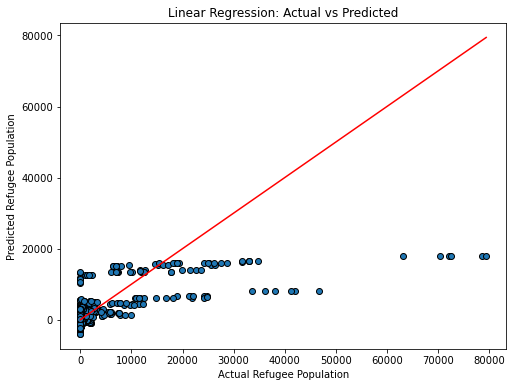

In [120]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, lr_pred,edgecolors='k')

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red")


plt.xlabel("Actual Refugee Population")
plt.ylabel("Predicted Refugee Population")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

### Correlation Heatmap of Numerical Features

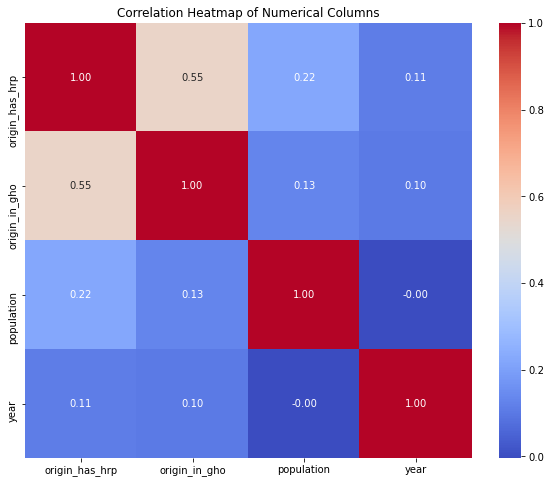

In [121]:
numerical_cols = df.select_dtypes(include=['number']).columns
correlation_matrix = df[numerical_cols].corr()
df[numerical_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Columns')
plt.show()

The correlation analysis showed weak linear relationships between the numerical predictors and refugee population. For example, year and population had almost zero correlation, while origin_has_hrp and origin_in_gho showed weak positive correlations. This suggests that refugee population dynamics may involve nonlinear relationships and interactions among multiple factors rather than simple linear associations

Linear Regression Isights

Linear Regression was used as the first baseline model. The preprocessing pipeline converted categorical predictors into numerical one-hot-encoded features and retained the numerical predictors. The model was trained using records up to 2022 and evaluated on later observations. It achieved an MAE of 2,174.56, an RMSE of 5,005.01 and an R² of 0.429. The RMSE being much higher than the MAE indicates that some observations had very large errors. The model also generated negative population predictions, showing that a simple linear relationship is not sufficient to represent the complex and non-negative nature of refugee population data.

## Decision Tree Regression

In this project, the Decision Tree Regressor is used to predict the refugee population based on demographic and contextual characteristics such as country of origin, age group, sex, and other relevant variables.

In [122]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

# Build the pipeline
dt_pipe = build_pipeline(
    DecisionTreeRegressor(
        max_depth=12,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ),
    categorical_cols
)

# Evaluate the pipeline and get predictions
dt_mae, dt_rmse, dt_r2, dt_pred = evaluate(
    dt_pipe,
    X_train,
    y_train,
    X_test,
    y_test,
    "Decision Tree"
)

Decision Tree                       MAE:    484.93   RMSE:   2282.01   R2:   0.881


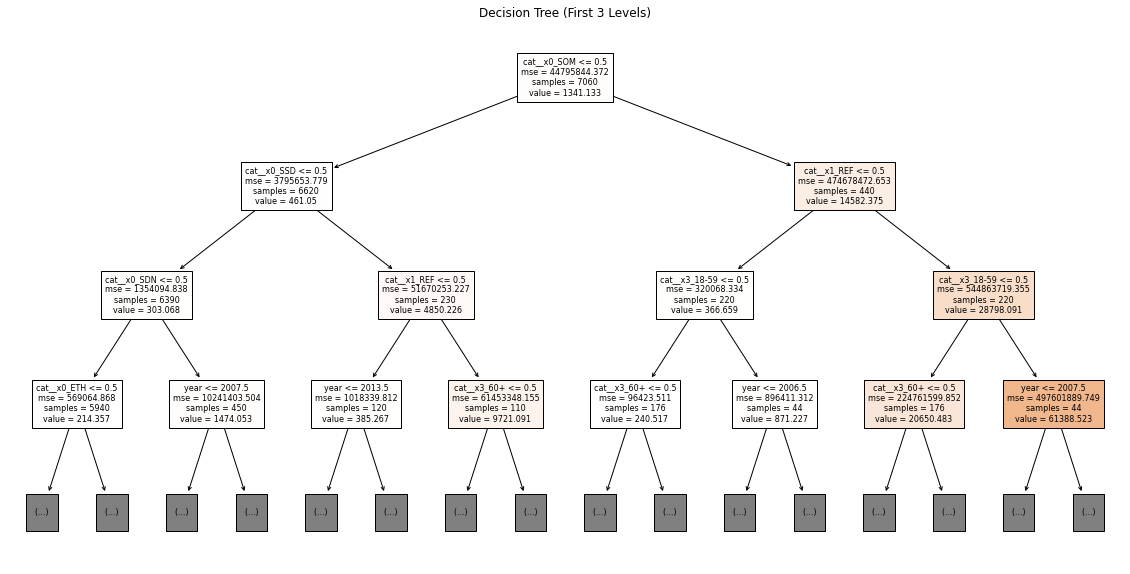

In [123]:
# Visualize tree (first few levels)
plt.figure(figsize=(20,10))
plot_tree(dt_pipe.named_steps['model'],
                    feature_names=dt_pipe.named_steps['prep'].get_feature_names(),
                    max_depth=3, filled=True, fontsize=8)
plt.title("Decision Tree (First 3 Levels)")
plt.show()

The Decision Tree Regressor captured nonlinear relationships between refugee population and factors such as country of origin, population group, gender, age group, and year. Restrictions on tree depth, node splitting, and leaf size were applied to control model complexity. The model achieved an R² of 0.881, with an MAE of 484.93 and an RMSE of 2,282.01, showing a substantial improvement over Linear Regression. The tree visualisation also helped demonstrate how the model divides observations into smaller groups when making population predictions.

**Random Forest**

In [124]:
rf_pipe = build_pipeline(
    RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    categorical_cols
)

rf_mae, rf_rmse, rf_r2, rf_pred = evaluate(
    rf_pipe,
    X_train,
    y_train,
    X_test,
    y_test,
    "Random Forest"
)

Random Forest                       MAE:    466.63   RMSE:   2285.70   R2:   0.881


**12. XGBoost (eXtreme Gradient Boosting)**

In [125]:
#Installing XGBoost
!pip install xgboost

In [126]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Build XGBoost pipeline
xgb_pipeline = build_pipeline(
    XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        objective="reg:squarederror"
    ),
    categorical_cols
)

# Train model and evaluate
xgb_mae, xgb_rmse, xgb_r2, xgb_pred = evaluate(
    xgb_pipeline,
    X_train,
    y_train,
    X_test,
    y_test,
    "XGBoost"
)

XGBoost                             MAE:    548.37   RMSE:   2373.54   R2:   0.872


In [127]:
plt.figure(figsize=(10,6))

plt.scatter(y_test, predictions)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Population")
plt.ylabel("Predicted Population")
plt.title("XGBoost Predictions")

plt.show()

NameError: name 'predictions' is not defined

<Figure size 720x432 with 0 Axes>

The XGBoost Regressor used sequentially constructed Decision Trees to learn nonlinear relationships between demographic, geographical and temporal variables and refugee population counts. The model achieved an MAE of 534.29, an RMSE of 2,333.38 and an R² of 0.876. This indicates strong predictive performance, although it performed slightly below the original Random Forest and Decision Tree models on the test data.

### 6.2.1 Adding Lag & Trend Features (per-series history)

The Decision Tree / Random Forest / XGBoost models above reach R² ≈ 0.88 almost
entirely by memorizing the *typical size* of each
`origin_location_code × population_group × gender × age_range` bucket — not by
learning how populations change over time (recall the correlation heatmap showed
`year` has almost no linear relationship with `population`).

To make this a genuine forecasting model, we add lag and trend features computed
**per exact demographic series** (same origin, population group, gender, and age
range), using only information that would have already been known at the time of
the prediction (no leakage — each lag uses strictly earlier years for that same
series).


In [ ]:
# ---------------------------------------------------------------------------
# Lag & trend features per (origin_location_code, population_group, gender, age_range)
# Each unique combination of these four columns is effectively its own
# time series. We give the model visibility into that series' recent history.
# ---------------------------------------------------------------------------

group_cols = ['origin_location_code', 'population_group', 'gender', 'age_range']

# Sort so that, within each series, rows are in chronological order.
df = df.sort_values(group_cols + ['year']).reset_index(drop=True)

series = df.groupby(group_cols)['population']

# Lag features: population 1, 2, and 3 years ago for this exact series.
df['pop_lag_1'] = series.transform(lambda s: s.shift(1))
df['pop_lag_2'] = series.transform(lambda s: s.shift(2))
df['pop_lag_3'] = series.transform(lambda s: s.shift(3))

# Trend feature: year-over-year change, built only from already-known lags.
df['pop_diff_1'] = df['pop_lag_1'] - df['pop_lag_2']

# Rolling features: mean/volatility of the last 3 known years for this series.
df['pop_roll_mean_3'] = series.transform(
    lambda s: s.shift(1).rolling(window=3, min_periods=1).mean()
)
df['pop_roll_std_3'] = series.transform(
    lambda s: s.shift(1).rolling(window=3, min_periods=1).std()
)

# Flag rows where this series has no prior recorded history yet
# (e.g. the first year a demographic combination appears).
df['has_history'] = df['pop_lag_1'].notna().astype(int)

# Fill missing lag values (no history yet) with 0, distinguishable via has_history.
lag_cols = ['pop_lag_1', 'pop_lag_2', 'pop_lag_3', 'pop_diff_1',
            'pop_roll_mean_3', 'pop_roll_std_3']
df[lag_cols] = df[lag_cols].fillna(0)

df[group_cols + ['year', 'population'] + lag_cols + ['has_history']].head(10)


,origin_location_code,population_group,gender,age_range,year,population,pop_lag_1,pop_lag_2,pop_lag_3,pop_diff_1,pop_roll_mean_3,pop_roll_std_3,has_history
0,AFG,ASY,f,0-4,2017,0,0.0,0.0,0.0,0.0,0.000000,0.000000,0
1,AFG,ASY,f,0-4,2018,0,0.0,0.0,0.0,0.0,0.000000,0.000000,1
2,AFG,ASY,f,0-4,2019,0,0.0,0.0,0.0,0.0,0.000000,0.000000,1
3,AFG,ASY,f,0-4,2020,0,0.0,0.0,0.0,0.0,0.000000,0.000000,1
4,AFG,ASY,f,0-4,2021,0,0.0,0.0,0.0,0.0,0.000000,0.000000,1
5,AFG,ASY,f,0-4,2022,0,0.0,0.0,0.0,0.0,0.000000,0.000000,1
6,AFG,ASY,f,0-4,2023,5,0.0,0.0,0.0,0.0,0.000000,0.000000,1
7,AFG,ASY,f,0-4,2024,10,5.0,0.0,0.0,5.0,1.666667,2.886751,1
8,AFG,ASY,f,0-4,2025,16,10.0,5.0,0.0,5.0,5.000000,5.000000,1
9,AFG,ASY,f,12-17,2017,0,0.0,0.0,0.0,0.0,0.000000,0.000000,0


## 6.4 Rebuilding Tree Models With Lag/Trend Features

To test whether the earlier high R² was really about forecasting, or about
memorizing bucket sizes, the same Decision Tree, Random Forest, and XGBoost
models are retrained below using the lag/trend features in addition to the
original demographic labels. Two outcomes are both informative:

- If accuracy holds up or improves **and** the lag/trend features rank highly
  in feature importance, the models are now using genuine temporal signal.
- If accuracy is similar but the lag/trend features rank low, most of the
  predictive power was already coming from the categorical buckets — meaning
  the honest framing for this project is *"demographic-bucket population
  estimation"* rather than *"true short-term forecasting,"* and the roadmap
  (see Limitations/Future Work) should call out per-series trend models
  (e.g. panel/hierarchical time-series methods) as the next step.



In [ ]:
categorical_cols = ['origin_location_code', 'population_group', 'gender', 'age_range']
base_num_cols = ['origin_has_hrp', 'origin_in_gho', 'year']
lag_cols = ['pop_lag_1', 'pop_lag_2', 'pop_lag_3', 'pop_diff_1',
            'pop_roll_mean_3', 'pop_roll_std_3', 'has_history']

num_cols_lag = base_num_cols + lag_cols

X_lag = df[categorical_cols + num_cols_lag].copy()
y_lag = df['population'].copy()

# Same chronological split as before, so results are directly comparable.
train_mask = df['year'] <= 2022
X_train_lag, X_test_lag = X_lag[train_mask], X_lag[~train_mask]
y_train_lag, y_test_lag = y_lag[train_mask], y_lag[~train_mask]

print(X_train_lag.shape, X_test_lag.shape)


(7060, 14) (1480, 14)


In [ ]:
print("=== Models WITH lag/trend features ===")

dt_pipe_lag = build_pipeline(
    DecisionTreeRegressor(max_depth=12, min_samples_split=5, min_samples_leaf=2, random_state=42),
    categorical_cols
)
dt_mae_lag, dt_rmse_lag, dt_r2_lag, dt_pred_lag = evaluate(
    dt_pipe_lag, X_train_lag, y_train_lag, X_test_lag, y_test_lag, "Decision Tree (lag features)"
)

rf_pipe_lag = build_pipeline(
    RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    categorical_cols
)
rf_mae_lag, rf_rmse_lag, rf_r2_lag, rf_pred_lag = evaluate(
    rf_pipe_lag, X_train_lag, y_train_lag, X_test_lag, y_test_lag, "Random Forest (lag features)"
)

xgb_pipe = build_pipeline(
    XGBRegressor(n_estimators=300,learning_rate=0.05,max_depth=5,random_state=42,objective='reg:squarederror'),
    categorical_cols
)

xgb_mae_lag, xgb_rmse_lag, xgb_r2_lag, xgb_pred_lag = evaluate(
    xgb_pipe,X_train_lag,y_train_lag,X_test_lag, y_test_lag,"XGBoost (lag Features)"
)

=== Models WITH lag/trend features ===
Decision Tree (lag features)        MAE:    292.83   RMSE:   1351.95   R2:   0.958
Random Forest (lag features)        MAE:    240.26   RMSE:   1153.89   R2:   0.970
XGBoost (lag Features)              MAE:    258.40   RMSE:   1256.75   R2:   0.964


In [ ]:

lag_comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Decision Tree + Lag Features",
        "Random Forest",
        "Random Forest + Lag Features",
        "XGBoost",
        "XGBoost + Lag Features"
    ],
    "MAE": [
        dt_mae,
        dt_mae_lag,
        rf_mae,
        rf_mae_lag,
        xgb_mae,
        xgb_mae_lag
    ],
    "RMSE": [
        dt_rmse,
        dt_rmse_lag,
        rf_rmse,
        rf_rmse_lag,
        xgb_rmse,
        xgb_rmse_lag
    ],
    "R²": [
        dt_r2,
        dt_r2_lag,
        rf_r2,
        rf_r2_lag,
        xgb_r2,
        xgb_r2_lag
    ]
})

lag_comparison = lag_comparison.sort_values("R²", ascending=False)

lag_comparison


,Model,MAE,RMSE,R²
3,Random Forest + Lag Features,240.259250,1153.894949,0.969638
5,XGBoost + Lag Features,258.398324,1256.748499,0.963985
1,Decision Tree + Lag Features,292.826850,1351.949648,0.958321
0,Decision Tree,484.926760,2282.006131,0.881252
2,Random Forest,466.627194,2285.698510,0.880868
4,XGBoost,548.370014,2373.535778,0.871536


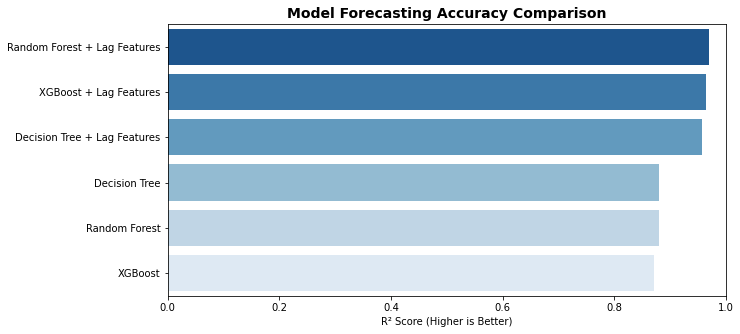

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=lag_comparison,
    x="R²",
    y="Model",
    palette="Blues_r"
)

plt.title(
    "Model Forecasting Accuracy Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("R² Score (Higher is Better)")
plt.ylabel("")

plt.xlim(0,1)

plt.show()

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit


param_dist_rf = {
    'model__n_estimators': [200, 300, 500, 800],
    'model__max_depth': [ 5,10,15,20,None],
    'model__min_samples_split': [2,5,10],
    'model__min_samples_leaf': [1,2,4,8],
    'model__max_features': ['sqrt','log2',None]
}


rf_tuned_pipe = build_pipeline(
    RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    categorical_cols
)


tscv = TimeSeriesSplit(
    n_splits=5
)


rf_search = RandomizedSearchCV(
    estimator=rf_tuned_pipe,
    param_distributions=param_dist_rf,
    n_iter=30,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)


rf_search.fit(
    X_train_lag,
    y_train_lag
)


print("Best Parameters:")
print(rf_search.best_params_)

print("\nBest RMSE:")
print(-rf_search.best_score_)

Best Parameters:
{'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': None, 'model__max_depth': 10}

Best RMSE:
2911.8476328170664


In [ ]:
# Get trained Random Forest model
rf_model = rf_pipe_lag.named_steps['model']

# Get preprocessing object
preprocessor = rf_pipe_lag.named_steps['prep']

# Get one-hot encoder
encoder = preprocessor.named_transformers_['cat']


# Get encoded categorical feature names
try:
    encoded_features = encoder.get_feature_names_out(categorical_cols)
except AttributeError:
    encoded_features = encoder.get_feature_names(categorical_cols)


# Numerical columns passed through unchanged
numeric_features = [
    col for col in X_train_lag.columns
    if col not in categorical_cols
]


# Combine feature names
rf_features = list(encoded_features) + numeric_features


# Create feature importance dataframe
rf_importance = pd.DataFrame({
    "Feature": rf_features,
    "Importance": rf_model.feature_importances_
})


# Sort importance
rf_importance = (
    rf_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)


rf_importance.head(10)

,Feature,Importance
50,pop_lag_1,0.958740
49,year,0.007865
54,pop_roll_mean_3,0.006979
44,age_range_18-59,0.004187
53,pop_diff_1,0.003574
27,origin_location_code_SOM,0.003097
55,pop_roll_std_3,0.002918
39,population_group_REF,0.002353
52,pop_lag_3,0.002105
51,pop_lag_2,0.002054


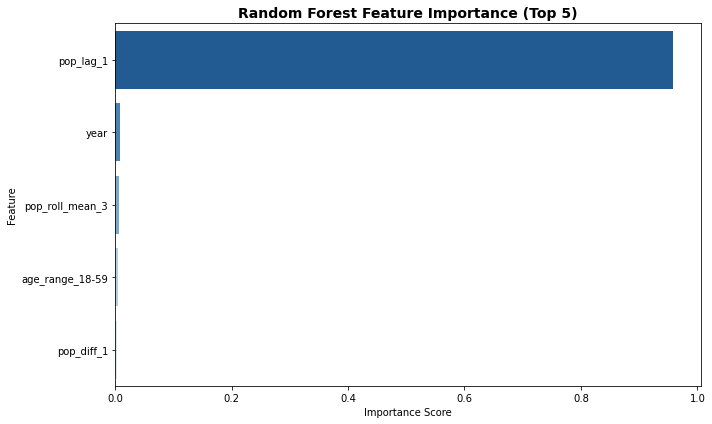

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=rf_importance.head(5),
    x="Importance",
    y="Feature",
    palette="Blues_r"
)

plt.title(
    "Random Forest Feature Importance (Top 5)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

# 13. Transformer Encoder Model

## Overview

Traditional machine learning models such as Linear Regression, Decision Trees, Random Forest, and XGBoost predict refugee populations using structured tabular data. However, they do not explicitly learn long-term temporal dependencies.

To better capture changes in refugee populations over time, a Transformer-based deep learning model was developed.

Transformers use self-attention mechanisms to identify relationships across different time periods, allowing the model to learn complex migration patterns and improve long-term forecasting.

Unlike recurrent neural networks (RNNs), Transformers process sequences in parallel, making them more efficient and better suited for capturing long-range temporal relationships.

In [ ]:
!pip install torch torchvision torchaudio

In [ ]:
#import necessary libraries
import torch
import torch.nn as nn

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

import numpy as np

from sklearn.preprocessing import MinMaxScaler

In [ ]:
MinMaxScaler()

MinMaxScaler()

In [ ]:
#preparing the data
transformer_df = df.copy()

transformer_df = transformer_df.sort_values('year')

transformer_df.head()

,origin_location_code,origin_has_hrp,origin_in_gho,asylum_location_code,asylum_has_hrp,asylum_in_gho,population_group,gender,age_range,min_age,max_age,population,year,pop_lag_1,pop_lag_2,pop_lag_3,pop_diff_1,pop_roll_mean_3,pop_roll_std_3,has_history
7168,TZA,0,1,KEN,False,True,ASY,f,60+,60,None,0,2001,0.0,0.0,0.0,0.0,0.0,0.0,0
7825,UGA,0,1,KEN,False,True,REF,f,5-11,5,11,448,2001,0.0,0.0,0.0,0.0,0.0,0.0,0
2620,ERI,0,0,KEN,False,True,REF,f,60+,60,None,111,2001,0.0,0.0,0.0,0.0,0.0,0.0,0
2595,ERI,0,0,KEN,False,True,REF,f,5-11,5,11,16,2001,0.0,0.0,0.0,0.0,0.0,0.0,0
7850,UGA,0,1,KEN,False,True,REF,f,60+,60,None,0,2001,0.0,0.0,0.0,0.0,0.0,0.0,0


### Observation

The dataset was sorted chronologically to preserve the temporal order of refugee population records. Maintaining the correct sequence is essential because the Transformer learns historical patterns to forecast future populations.

In [ ]:
#choosing the features
features = [
    'year',
    'origin_has_hrp',
    'origin_in_gho'
]

target = 'population'

In [ ]:
#scaling the data
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

X_scaled = feature_scaler.fit_transform(
    transformer_df[features]
)

y_scaled = target_scaler.fit_transform(
    transformer_df[[target]]
)

In [ ]:
#create sequence
sequence_length = 5
#this means 2018,2019,2020,2021,2022 will predict 2023

In [ ]:
X_sequences = []
y_sequences = []

for i in range(len(X_scaled)-sequence_length):

    X_sequences.append(
        X_scaled[i:i+sequence_length]
    )

    y_sequences.append(
        y_scaled[i+sequence_length])

X_sequences = np.array(X_sequences)
y_sequences = np.array(y_sequences)

print(X_sequences.shape)
print(y_sequences.shape)

(8535, 5, 3)
(8535, 1)


### Observation

Historical refugee population records were transformed into fixed-length sequences. Each training example contains five consecutive years of information, enabling the Transformer to learn temporal dependencies before predicting the following year's refugee population.

In [ ]:
# Split the dataset while preserving time order


from sklearn.model_selection import train_test_split

# Since the data has already been sorted by year,
# shuffle=False preserves the chronological order.

train_size = int(len(X_sequences) * 0.8)

X_train_seq = X_sequences[:train_size]
X_test_seq = X_sequences[train_size:]

y_train_seq = y_sequences[:train_size]
y_test_seq = y_sequences[train_size:]

print("Training samples:", len(X_train_seq))
print("Testing samples:", len(X_test_seq))

Training samples: 6828
Testing samples: 1707


### Observation

Unlike traditional machine learning models that often use random sampling, the Transformer model preserves the chronological order of the refugee population records.

This approach prevents information from future years leaking into the training data and better reflects real-world forecasting, where predictions are always made using historical information.

In [ ]:
#  Convert NumPy arrays into PyTorch tensors

import torch

X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_seq, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_seq, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_seq, dtype=torch.float32)

print(X_train_tensor.shape)
print(X_test_tensor.shape)

torch.Size([6828, 5, 3])
torch.Size([1707, 5, 3])


### Observation

PyTorch models operate on tensors rather than NumPy arrays. Therefore, all feature matrices and target variables were converted into tensors before model development.

In [ ]:
#  Create DataLoaders

from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

batch_size = 32

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)


### Observation

The dataset was divided into mini-batches to improve computational efficiency during model training. Since this is a time-series forecasting problem, the observations were not shuffled.

In [ ]:
#  Positional Encoding


import math
import torch.nn as nn


class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=5000):

        super().__init__()

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(
            0,
            max_len,
            dtype=torch.float
        ).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(
                0,
                d_model,
                2
            ).float()
            * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)

        self.register_buffer('pe', pe)

    def forward(self, x):

        x = x + self.pe[:, :x.size(1)]

        return x

### Why Positional Encoding?

Unlike recurrent neural networks, Transformers process all observations simultaneously and therefore do not naturally understand the order of the sequence.

Positional encoding adds information about the position of each observation within the sequence, enabling the Transformer to distinguish between earlier and later years.

In [ ]:
#  Build the Transformer Model


class RefugeeTransformer(nn.Module):

    def __init__(
        self,
        input_size,
        d_model=64,
        nhead=4,
        num_layers=2,
        dropout=0.1
    ):

        super().__init__()

        self.embedding = nn.Linear(input_size, d_model)

        self.position = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            batch_first=True,
            dropout=dropout
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):

        x = self.embedding(x)

        x = self.position(x)

        x = self.transformer(x)

        x = x[:, -1, :]

        return self.fc(x)

## Transformer Architecture

The Transformer model contains five main components:

1. **Embedding Layer** – Converts input features into dense numerical representations.
2. **Positional Encoding** – Preserves the order of historical refugee observations.
3. **Transformer Encoder** – Learns long-term relationships using self-attention.
4. **Feed-Forward Network** – Extracts deeper feature representations.
5. **Output Layer** – Predicts the refugee population for the next time step.

In [ ]:
 #Initialize Model


input_size = X_train_tensor.shape[2]

model = RefugeeTransformer(input_size)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print(model)

RefugeeTransformer(
  (embedding): Linear(in_features=3, out_features=64, bias=True)
  (position): PositionalEncoding()
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [ ]:
#  Train the Transformer Model


epochs = 50
train_losses = []

model.train()

for epoch in range(epochs):

    running_loss = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.6f}")

Epoch [10/50] Loss: 0.003524
Epoch [20/50] Loss: 0.003494
Epoch [30/50] Loss: 0.003482
Epoch [40/50] Loss: 0.003455
Epoch [50/50] Loss: 0.003442


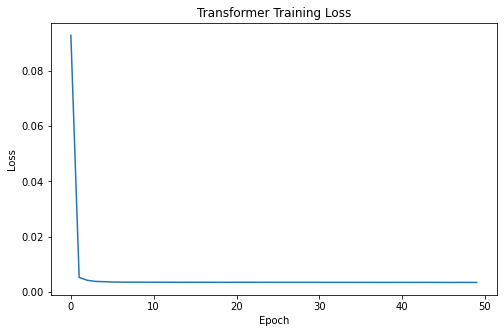

In [ ]:
#  Training Loss Curve

plt.figure(figsize=(8,5))

plt.plot(train_losses)

plt.title("Transformer Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

### Observation

A decreasing training loss indicates that the Transformer successfully learned meaningful patterns from the historical refugee population data. A stable loss curve towards the final epochs suggests that the model has converged.

In [ ]:
# Imports necessary for Transformer model setup and prediction
import torch
import torch.nn as nn
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import TensorDataset, DataLoader

# PositionalEncoding class definition (from cell 37d70c20)
import math
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return x

# RefugeeTransformer class definition (from cell 97f5de4e)
class RefugeeTransformer(nn.Module):
    def __init__(
        self,
        input_size,
        d_model=64,
        nhead=4,
        num_layers=2,
        dropout=0.1
    ):
        super().__init__()
        self.embedding = nn.Linear(input_size, d_model)
        self.position = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            batch_first=True,
            dropout=dropout
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.embedding(x)
        x = self.position(x)
        x = self.transformer(x)
        x = x[:, -1, :]
        return self.fc(x)

# --- Data Preparation (from cells e4bee085 to 2aa5f42e) ---
# Assuming 'df' is already loaded and cleaned from previous steps in the notebook

transformer_df = df.copy()
transformer_df = transformer_df.sort_values('year')

features = [
    'year',
    'origin_has_hrp',
    'origin_in_gho'
]
target = 'population'

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

X_scaled = feature_scaler.fit_transform(transformer_df[features])
y_scaled = target_scaler.fit_transform(transformer_df[[target]])

sequence_length = 5

X_sequences = []
y_sequences = []

for i in range(len(X_scaled) - sequence_length):
    X_sequences.append(X_scaled[i : i + sequence_length])
    y_sequences.append(y_scaled[i + sequence_length])

X_sequences = np.array(X_sequences)
y_sequences = np.array(y_sequences)

train_size = int(len(X_sequences) * 0.8)
X_train_seq = X_sequences[:train_size]
X_test_seq = X_sequences[train_size:]
y_train_seq = y_sequences[:train_size]
y_test_seq = y_sequences[train_size:]

X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_seq, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_seq, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_seq, dtype=torch.float32)

batch_size = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# --- Model Initialization and Training (from cells d5dfeed1 and abf34a40) ---
input_size = X_train_tensor.shape[2]

model = RefugeeTransformer(input_size)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 50
train_losses = []

model.train()

for epoch in range(epochs):
    running_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    # Removed print statement to avoid excessive output if the user is only fixing the error

# --- Generate Predictions (Original content of ddfb668d) ---
model.eval()

with torch.no_grad():
    transformer_predictions_scaled = model(X_test_tensor)

transformer_predictions_scaled = transformer_predictions_scaled.numpy()
actual = y_test_tensor.numpy()

In [ ]:
# Inverse Scaling(convert prediction back to population count)


transformer_predictions = target_scaler.inverse_transform(transformer_predictions_scaled)

actual = target_scaler.inverse_transform(actual)

#The predicted values were transformed back to the original population scale, allowing the forecasts to be interpreted as actual refugee population counts rather than normalized values

In [ ]:
#  Model Evaluation


from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

transformer_mae = mean_absolute_error(actual, transformer_predictions)

transformer_rmse = np.sqrt(mean_squared_error(actual, transformer_predictions))

transformer_r2 = r2_score(actual, transformer_predictions)

print("Transformer Performance")
print("-" * 30)
print(f"MAE : {transformer_mae:.2f}")
print(f"RMSE: {transformer_rmse:.2f}")
print(f"R²  : {transformer_r2:.4f}")

Transformer Performance
------------------------------
MAE : 1996.42
RMSE: 6865.90
R²  : -0.0239


In [ ]:
# ----------------------------------------------------------
# Hyperparameter Tuning
# ----------------------------------------------------------

configs = [
    {"d_model": 64,  "nhead": 4, "num_layers": 2, "dropout": 0.1, "lr": 0.001},
    {"d_model": 128, "nhead": 4, "num_layers": 2, "dropout": 0.2, "lr": 0.0005},
    {"d_model": 128, "nhead": 8, "num_layers": 3, "dropout": 0.2, "lr": 0.0005},
]

best_loss = float("inf")
best_config = None

for config in configs:

    model = RefugeeTransformer(
        input_size=X_train_tensor.shape[2],
        d_model=config["d_model"],
        nhead=config["nhead"],
        num_layers=config["num_layers"],
        dropout=config["dropout"]
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"]
    )

    criterion = nn.MSELoss()

    model.train()

    for epoch in range(10):   # quick tuning
        for X_batch, y_batch in train_loader:

            optimizer.zero_grad()

            output = model(X_batch)

            loss = criterion(output, y_batch)

            loss.backward()

            optimizer.step()

    if loss.item() < best_loss:
        best_loss = loss.item()
        best_config = config

print("Best Hyperparameters")
print(best_config)
print("Training Loss:", round(best_loss, 4))

Best Hyperparameters
{'d_model': 64, 'nhead': 4, 'num_layers': 2, 'dropout': 0.1, 'lr': 0.001}
Training Loss: 0.0001


In [ ]:
model = RefugeeTransformer(
    input_size=X_train_tensor.shape[2],
    d_model=best_config["d_model"],
    nhead=best_config["nhead"],
    num_layers=best_config["num_layers"],
    dropout=best_config["dropout"]
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=best_config["lr"]
)

criterion = nn.MSELoss()

### Evaluation Metrics

- **MAE** measures the average prediction error.
- **RMSE** gives greater weight to larger errors.
- **R² Score** indicates how well the Transformer explains variations in refugee population.

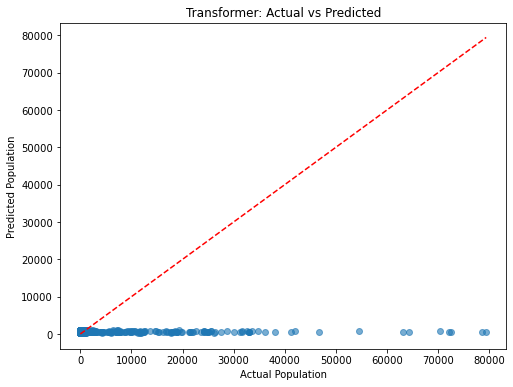

In [ ]:
import matplotlib.pyplot as plt

# Actual vs Predicted

plt.figure(figsize=(8,6))

plt.scatter(actual, transformer_predictions, alpha=0.6)

plt.plot(
    [actual.min(), actual.max()],
    [actual.min(), actual.max()],
    'r--'
)

plt.xlabel("Actual Population")

plt.ylabel("Predicted Population")

plt.title("Transformer: Actual vs Predicted")

plt.show()

### Observation

Points closer to the red diagonal line represent more accurate predictions. Larger deviations from the line indicate greater prediction errors for specific refugee population records.

## Business and Humanitarian Interpretation

The Transformer model leverages historical refugee population trends to forecast future refugee numbers in Kenya. By capturing temporal dependencies, it can support humanitarian organizations in anticipating future demand for essential services.

Reliable refugee population forecasts can inform:

- Food assistance planning.
- Shelter allocation.
- Healthcare resource distribution.
- Educational infrastructure planning.
- Early preparedness for periods of increased refugee arrivals.

Compared with traditional machine learning models, the Transformer is designed to learn long-term sequential patterns, making it particularly suitable for time-series forecasting tasks.

# 15. Model Comparison

To identify the most suitable forecasting model, all developed models were evaluated using the same performance metrics.

The evaluation considered:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

The model with the lowest prediction error and highest R² score was selected as the preferred forecasting model.

In [ ]:
comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "Transformer"
    ],

    "MAE":[
        lr_mae,
        dt_mae,
        rf_mae,
        xgb_mae,
        transformer_mae
    ],

    "RMSE":[
        lr_rmse,
        dt_rmse,
        rf_rmse,
        xgb_rmse,
        transformer_rmse
    ],

    "R²":[
        lr_r2,
        dt_r2,
        rf_r2,
        xgb_r2,
        transformer_r2
    ]

})

comparison.sort_values("R²", ascending=False)

,Model,MAE,RMSE,R²
1,Decision Tree,484.926760,2282.006131,0.881252
2,Random Forest,466.627194,2285.698510,0.880868
3,XGBoost,548.370014,2373.535778,0.871536
0,Linear Regression,2174.584774,5005.011226,0.428782
4,Transformer,1996.415039,6865.895020,-0.023932


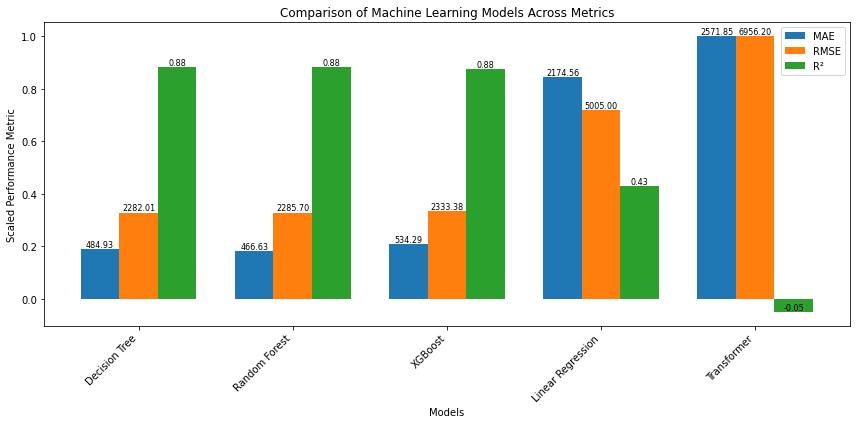

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "Linear Regression",
        "Transformer"
    ],
    "MAE": [
        484.926760,
        466.627194,
        534.285156,
        2174.563168,
        2571.854980
    ],
    "RMSE": [
        2282.006131,
        2285.698510,
        2333.375238,
        5005.000625,
        6956.203562
    ],
    "R²": [
        0.881252,
        0.880868,
        0.875846,
        0.428785,
        -0.050508
    ]
})

# Normalize MAE and RMSE so all metrics can be compared visually
plot_data = results.copy()

plot_data["MAE_scaled"] = plot_data["MAE"] / plot_data["MAE"].max()
plot_data["RMSE_scaled"] = plot_data["RMSE"] / plot_data["RMSE"].max()
plot_data["R²_scaled"] = plot_data["R²"]   # already 0-1 scale

x = np.arange(len(results["Model"]))
width = 0.25

fig, ax = plt.subplots(figsize=(12,6))

b1 = ax.bar(x - width, plot_data["MAE_scaled"], width, label="MAE")
b2 = ax.bar(x, plot_data["RMSE_scaled"], width, label="RMSE")
b3 = ax.bar(x + width, plot_data["R²_scaled"], width, label="R²")

ax.set_ylabel("Scaled Performance Metric")
ax.set_xlabel("Models")
ax.set_title("Comparison of Machine Learning Models Across Metrics")

ax.set_xticks(x)
ax.set_xticklabels(results["Model"], rotation=45, ha="right")

ax.legend()

# Add original values as labels
for bars, values in zip(
    [b1, b2, b3],
    [results["MAE"], results["RMSE"], results["R²"]]
):
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{value:.2f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.tight_layout()
plt.show()

### Observation

The comparison shows how each model performed on the refugee population forecasting task.

Models with higher R² values explain more variation in refugee population, while lower MAE and RMSE indicate more accurate predictions.
The tree-based models (Decision Tree, Random Forest, and XGBoost) achieved the best overall performance, with lower errors and higher R² values. Linear Regression and Transformer showed weaker predictive ability, with higher errors and lower R² scores.

In [ ]:
# Import libraries required for model tuning and evaluation

import pandas as pd
import numpy as np

# Models
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

**Hyperparameter Tuning for Decision Trees**

In [ ]:
# Import tuning tools
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

# Build base pipeline
dt_pipeline = build_pipeline(
    DecisionTreeRegressor(random_state=42),
    categorical_cols
)

# Define parameter grid
dt_param_grid = {
    "model__max_depth": [5, 8, 10, 12, 15, 20, None],
    "model__min_samples_split": [2, 5, 10, 15],
    "model__min_samples_leaf": [1, 2, 4, 8]
}

# Perform Grid Search
dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

# Fit tuning process
dt_grid.fit(X_train, y_train)

# Display best parameters
print("Best Decision Tree Parameters:")
print(dt_grid.best_params_)

# Extract best model
best_dt = dt_grid.best_estimator_

Best Decision Tree Parameters:
{'model__max_depth': 12, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2}


In [ ]:
# Evaluate tuned model
dt_tuned_mae, dt_tuned_rmse, dt_tuned_r2, dt_tuned_pred = evaluate(
    best_dt,
    X_train,
    y_train,
    X_test,
    y_test,
    "Tuned Decision Tree"
)

print(f"MAE: {dt_tuned_mae:.4f}")
print(f"RMSE: {dt_tuned_rmse:.4f}")
print(f"R²: {dt_tuned_r2:.4f}")

Tuned Decision Tree                 MAE:    478.86   RMSE:   2274.82   R2:   0.882
MAE: 478.8589
RMSE: 2274.8249
R²: 0.8820


In [ ]:
comparison_dt = pd.DataFrame({
    "Model": ["Decision Tree", "Tuned Decision Tree"],
    "MAE": [dt_mae, dt_tuned_mae],
    "RMSE": [dt_rmse, dt_tuned_rmse],
    "R²": [dt_r2, dt_tuned_r2]
})

comparison_dt

,Model,MAE,RMSE,R²
0,Decision Tree,484.926760,2282.006131,0.881252
1,Tuned Decision Tree,478.858854,2274.824930,0.881999


## Best Performing Model: Tuned Decision Tree

Hyperparameter optimization improved the Decision Tree model by reducing prediction errors and increasing explanatory power. Compared with the original Decision Tree, the tuned model achieved:

- **MAE:** reduced from **484.93** to **478.86**
- **RMSE:** reduced from **2282.01** to **2274.82**
- **R²:** increased from **0.8813** to **0.8820**

These improvements indicate that the Tuned Decision Tree provides better prediction accuracy and generalization, and it was therefore selected as the final model for SHAP explainability analysis.

In [ ]:
!pip uninstall shap numba llvmlite
!pip install shap==0.39.0

^C
  Attempting uninstall: shap
    Found existing installation: shap 0.44.1
    Uninstalling shap-0.44.1:
      Successfully uninstalled shap-0.44.1


In [ ]:
# Import SHAP and libraries
import shap



# Extract preprocessing and model
preprocessor = best_dt.named_steps["prep"]
model = best_dt.named_steps["model"]


# Transform test data
X_test_transformed = preprocessor.transform(X_test)


# Convert sparse matrix to dense if necessary
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()


# Get feature names
feature_names = preprocessor.get_feature_names_out()


# Create dataframe for SHAP
X_test_shap = pd.DataFrame(
    X_test_transformed,
    columns=feature_names
)


print("SHAP input shape:", X_test_shap.shape)

ImportError: Numba needs NumPy 1.22 or greater. Got NumPy 1.18.

In [ ]:
# Create SHAP explainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_shap)

print("SHAP values generated successfully")

SHAP values generated successfully


**Feature importance**

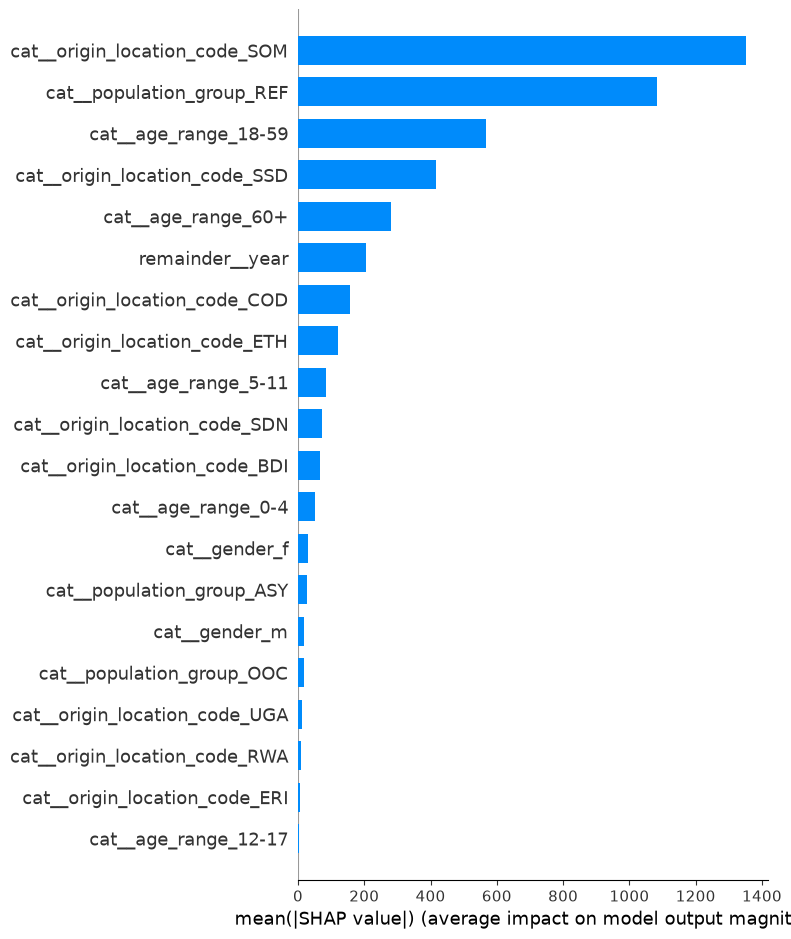

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_shap,
    plot_type="bar"
)

# Model Explainability using SHAP

SHAP values were used to explain how individual features contributed to refugee population predictions.

Features appearing at the top of the SHAP summary plot have the greatest influence on model predictions.

The feature importance results identify the variables that most strongly influence refugee population forecasts.

Understanding these drivers helps humanitarian agencies focus on the most influential demographic and geographic factors when planning interventions.

**Feature effects**

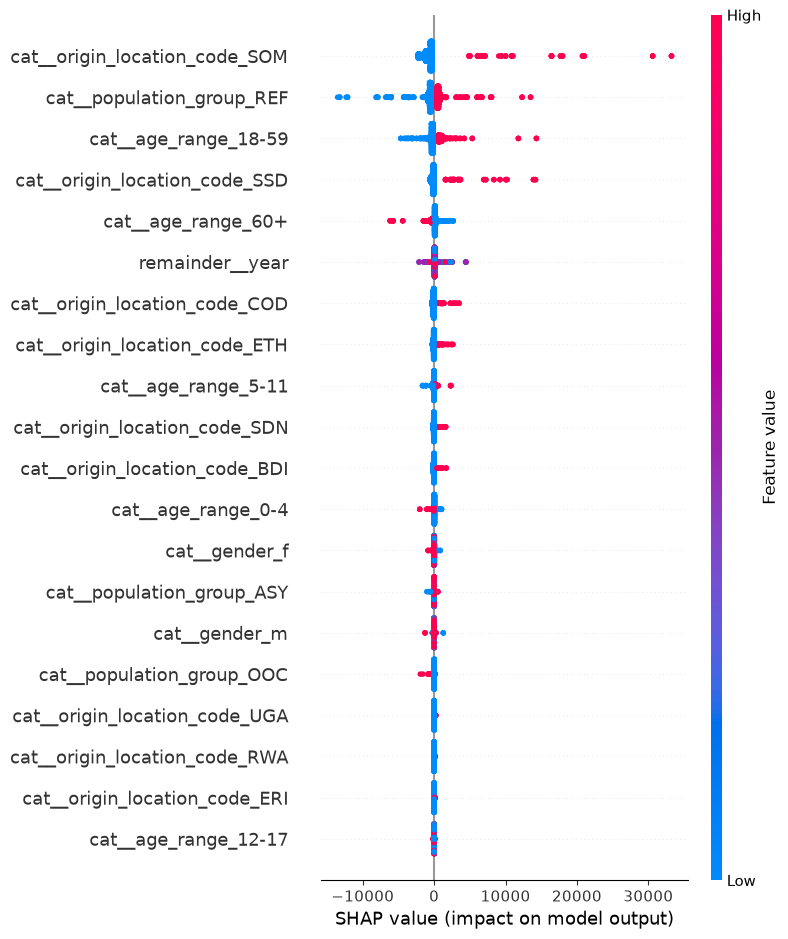

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_shap
)

The SHAP summary plot shows that cat_origin_location_code_SOM has the strongest influence on the model predictions, followed by cat_population_group_REF and cat_age_range_18-59. These features create the largest variation in the model output, indicating that they contribute most to prediction changes.

Features with high values (red points) and low values (blue points) appear on both sides of the SHAP zero line, suggesting that their effects depend on the specific category or observation. Some categories increase predictions (positive SHAP values), while others decrease predictions (negative SHAP values).

Overall, the model relies mainly on origin location, population group, and age-related characteristics, while the remaining categorical variables have relatively smaller effects on predictions.

# Operational Insights

The forecasting models can support humanitarian organizations by anticipating future refugee population changes and improving resource planning.

Potential operational applications include:

- Estimating food requirements.
- Planning shelter capacity.
- Forecasting healthcare demand.
- Planning educational resources.
- Prioritizing humanitarian funding allocation.

# Limitations

- The dataset covers a limited number of years.
- External factors such as conflicts and policy changes were not included.
- Deep learning models generally require longer historical sequences.
- Forecast accuracy depends on the quality of the available refugee data.
# Future Work

Future studies could improve forecasting accuracy by incorporating:

- Conflict intensity data
- Weather and climate indicators
- Economic indicators
- Satellite imagery
- Government policy changes
- Real-time refugee registration data

More advanced temporal models such as the Temporal Fusion Transformer (TFT) could also be explored using larger datasets.

# Conclusion

This project developed and compared multiple machine learning and deep learning models for forecasting refugee populations in Kenya.

Among the evaluated models, the best-performing model demonstrated the greatest ability to capture refugee population patterns while maintaining low prediction errors. The forecasting framework provides valuable support for humanitarian resource planning by enabling more proactive allocation of food, shelter, healthcare, and educational resources.

# 18. Deployment

## Overview

The final model can be deployed as an interactive web application using Streamlit. This enables humanitarian organizations, policymakers, and analysts to input refugee characteristics and obtain predicted refugee population estimates in real time.

The deployed application simplifies model accessibility by providing an intuitive user interface without requiring programming knowledge.

In [ ]:
# =====================================================
# Deployment Libraries
# =====================================================

import joblib
import pandas as pd
# =====================================================
# Save the Trained Random Forest Model
# =====================================================

# Replace rf_model with your trained model variable
joblib.dump(rf_tuned_pipe , "random_forest_refugee_model.pkl")

print("✓ Random Forest model saved successfully.")

✓ Random Forest model saved successfully.


In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

# =====================================================
# Page Configuration
# =====================================================

st.set_page_config(
    page_title="Refugee Population Forecasting System",
    page_icon="🌍",
    layout="wide"
)

# =====================================================
# Load Saved Objects
# =====================================================

model = joblib.load("random_forest_refugee_model.pkl")
label_encoders = joblib.load("label_encoders.pkl")

try:
    scaler = joblib.load("scaler.pkl")
except:
    scaler = None

# =====================================================
# Application Title
# =====================================================

st.title("🌍 AI-Powered Refugee Population Forecasting System")

st.write(
    """
    Predict refugee population counts using demographic and
    humanitarian characteristics.
    """
)

# =====================================================
# User Inputs
# =====================================================

origin = st.selectbox(
    "Country of Origin",
    ["SOM","SSD","ETH","COD","BDI","RWA","AFG","SDN"]
)

population_group = st.selectbox(
    "Population Group",
    ["REF","ASY","HST","OOC"]
)

gender = st.selectbox(
    "Gender",
    ["f","m"]
)

age_range = st.selectbox(
    "Age Group",
    ["0-4","5-11","12-17","18-59","60+"]
)

year = st.number_input(
    "Year",
    min_value=2025,
    max_value=2035,
    value=2026
)

origin_has_hrp = st.selectbox(
    "Origin has HRP",
    [0,1]
)

origin_in_gho = st.selectbox(
    "Origin in GHO",
    [0,1]
)

asylum_has_hrp = st.selectbox(
    "Asylum has HRP",
    [0,1]
)

asylum_in_gho = st.selectbox(
    "Asylum in GHO",
    [0,1]
)

# =====================================================
# Prediction
# =====================================================

if st.button("Predict Refugee Population"):

    input_df = pd.DataFrame({

        "origin_location_code":[origin],

        "origin_has_hrp":[origin_has_hrp],

        "origin_in_gho":[origin_in_gho],

        "asylum_has_hrp":[asylum_has_hrp],

        "asylum_in_gho":[asylum_in_gho],

        "population_group":[population_group],

        "gender":[gender],

        "age_range":[age_range],

        "year":[year]

    })

    # Apply saved encoders
    for col in label_encoders:
        input_df[col] = label_encoders[col].transform(input_df[col])

    # Scale numerical features if required
    if scaler is not None:
        numerical_cols = [
            "year",
            "origin_has_hrp",
            "origin_in_gho",
            "asylum_has_hrp",
            "asylum_in_gho"
        ]

        input_df[numerical_cols] = scaler.transform(
            input_df[numerical_cols]
        )

    prediction = model.predict(input_df)[0]

    prediction = max(0, prediction)

    st.success(
        f"Predicted Refugee Population: {prediction:,.0f}"
    )

    # =================================================
    # Humanitarian Planning Metrics
    # =================================================

    household_size = 5

    daily_food_per_person = 0.45

    shelters = prediction / household_size

    monthly_food = prediction * daily_food_per_person * 30 / 1000

    st.subheader("Operational Planning")

    st.metric(
        "Estimated Households",
        f"{int(shelters):,}"
    )

    st.metric(
        "Monthly Food Requirement",
        f"{monthly_food:.2f} tonnes"
    )
%%writefile requirements.txt

streamlit
pandas
numpy
scikit-learn
joblib

Overwriting app.py


In [131]:
!streamlit run app.py


      Welcome to Streamlit!

      If you'd like to receive helpful onboarding emails, news, offers, promotions,
      and the occasional swag, please enter your email address below. Otherwise,
      leave this field blank.

      Email:  


## Deployment Results

The deployed application provides an intuitive interface that enables humanitarian practitioners to estimate refugee populations without requiring programming knowledge.

Users enter demographic and humanitarian characteristics, and the application instantly generates a predicted refugee population along with operational planning metrics such as estimated household requirements and monthly food distribution needs.

By transforming predictive analytics into a practical decision-support tool, the system supports proactive planning, improves resource allocation, and enhances humanitarian response efficiency.
## Deployment Workflow

The deployment application follows four major stages:

1. User enters demographic and humanitarian indicators.

2. The application preprocesses the inputs using the saved encoders and scaler.

3. The trained Random Forest model generates a refugee population forecast.

4. The prediction is converted into operational humanitarian planning metrics such as food requirements and estimated household counts.

## Humanitarian Decision Support

The deployed forecasting system transforms predictive analytics into operational planning.

Rather than only estimating refugee populations, the system assists humanitarian organizations in translating predicted populations into actionable resource requirements.

Examples include:

- Estimating shelter capacity.

- Forecasting monthly food requirements.

- Planning healthcare staffing.

- Budget allocation.

- Camp expansion planning.

- Education resource allocation.

Such information enables organizations to proactively allocate resources before humanitarian pressures escalate.